# Cross integration

**Cross integration** has several batches in which **all** modalities are present; the task is removing batch effects while keeping biological structure. Spatial registration (PASTE, PASTE2, SPIRAL, GPSA) also lives under `cross` - see the note at the end.

This tutorial covers, end to end:

- installing the package and the per-method environments
- the on-disk data layout this category expects
- seeing what runs on a dataset (`scan`) and what each method exposes for tuning
- running one method live and reading its metrics
- the standard figures: a per-dataset panel and an across-datasets summary
- **running the same pipeline on your own dataset**, demonstrated for real

**Reference dataset:** `D52` (23,478 cells). The stored results shipped
with these notebooks were produced on it, so every table below reproduces.

**Contents** - 1 Install · 2 Data layout · 3 What can I run · 4 Paper coverage ·
5 What can I tune · 6 Run one method · 7 Reading the metrics · 8 Figures ·
9 Your own dataset · Troubleshooting

## 1. Install

Prerequisites: Linux and `conda` (mamba recommended). `multibench` is not on
PyPI yet; the cell below installs it from the repository (~2 MB) and skips
itself when the package is already present:

In [1]:
import importlib.util

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:   # parent namespace absent (e.g. no `google`)
        return False

if not _has("multibench"):
    IN_COLAB = _has("google.colab")
    !git clone --depth 1 https://github.com/DSichang/scMultiBench.git
    %cd scMultiBench
    if IN_COLAB:
        # --no-deps keeps Colab's preinstalled numpy/pandas untouched;
        # everything the API needs is already there
        !pip -q install -e . --no-deps
    else:
        !pip -q install -e .
else:
    print("multibench already installed - skipping")

multibench already installed - skipping


The package itself is tiny; disk goes to the **conda environments of the
methods you choose to run**. The next cell shows which environments exist on
this machine; the commented lines build them - uncomment ONLY the tier you
need (running methods requires Linux + conda; on Colab you can still run
everything from section 7 on, which uses the shipped results):

- one method: its env only, 2-14 GB
- this tutorial's category (cross): ~71 GB (11 envs)
- the whole benchmark: 29 envs, 175 GB (~50 min build; drop the 52 GB package
  cache afterwards with `conda clean -a` - details in `SETUP.md`)

Each method runs in its **own conda environment** (they need mutually
incompatible framework versions), so the wrapper can run torch 1.x, torch 2.x,
TensorFlow and R methods in one sweep. `env install` is a dry run until you
add `--run`, and it skips environments that already exist.

**On Colab** there is no conda, so the two cells that execute methods will say
so and skip - everything else in this notebook, including the reference data
(auto-downloaded), the scans and every figure, runs for real.

In [2]:
import sys
!{sys.executable} -m multibench env doctor
# Uncomment the tier you need:
# !{sys.executable} -m multibench env install --methods StabMap --run   # one method (2-14 GB)
# !{sys.executable} -m multibench env install --category cross --run    # this category (~71 GB (11 envs))
# !{sys.executable} -m multibench env install --run                     # whole benchmark (175 GB)

[x] scmb_r             ( 5) <- Conos, StabMap, UINMF, iNMF, online_iNMF
[x] scmb_torch         ( 5) <- MultiMAP, SCALEX, scBridge, scMoMaT, uniPort
[x] env_sciPENN        ( 2) <- SMILE, sciPENN
[x] paste_envi         ( 2) <- PASTE, PASTE2
[x] scmb_seurat5       ( 2) <- Seurat_WNN, Seurat_v5
[x] MOFA2_env          ( 1) <- MOFA2
[x] env_moETM          ( 1) <- moETM
[x] glue               ( 1) <- GLUE
[x] matilda            ( 1) <- Matilda
[x] scmb_cobolt3       ( 1) <- Cobolt
[x] scmb_concerto      ( 1) <- Concerto
[x] scmb_gpsa2         ( 1) <- GPSA
[x] scmb_ipolng2       ( 1) <- iPOLNG
[x] scmb_mira          ( 1) <- MIRA
[x] scmb_multigrate2   ( 1) <- Multigrate
[x] scmb_multivi       ( 1) <- MultiVI
[x] scmb_scican        ( 1) <- sciCAN
[x] scmb_scjoint       ( 1) <- scJoint
[x] scmb_scmdc         ( 1) <- scMDC
[x] scmb_scmm2         ( 1) <- scMM
[x] scmb_scmsi         ( 1) <- scMSI
[x] scmb_scmvp4        ( 1) <- scMVP
[x] scmb_scvi          ( 1) <- totalVI
[x] scmb_seurat4b      ( 1)

In [3]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

# stored sweep results ship with the repository; resolve them whether this
# notebook runs from notebooks/ (its home) or from the repository root (Colab)
RESULTS = Path("results") if Path("results").exists() else Path("notebooks/results")
print("multibench", mtb.__version__)

multibench 0.1.0


In [4]:
DATASET  = "D52"
CATEGORY = "cross"

# This tutorial's reference data (D52 179 MB) downloads automatically from
# the repository's release assets when missing - nothing to fetch by hand.
import shutil, tarfile, urllib.request
NEED = ['D52']
LIVE_METHODS = ['StabMap', 'UINMF', 'sciPENN']
DATA_URL = "https://github.com/DSichang/scMultiBench/releases/download/data-v1"
root = mtb.config.DEFAULT.data_path
for _ds in NEED:
    if not (root / _ds).is_dir():
        try:
            root.mkdir(parents=True, exist_ok=True)
            print(f"downloading {_ds} from the release assets ...", flush=True)
            _tgz, _ = urllib.request.urlretrieve(f"{DATA_URL}/{_ds}.tar.gz")
            with tarfile.open(_tgz) as _t:
                _t.extractall(root)
        except Exception as _e:
            print(f"could not download {_ds} ({_e}) - see 'Get the data' in the installation guide")
HAVE_DATA = all((root / _d).is_dir() for _d in NEED)

# Running a method needs its conda environment; check what THIS machine can do
# and, when something is missing, say exactly how to get it.
CAN_RUN, _note = False, ""
if not HAVE_DATA:
    _note = "data unavailable, so the live-run cells will skip"
elif shutil.which("conda") is None and shutil.which("mamba") is None:
    _note = ("no conda here (Colab included) - the two live-run cells will skip; "
             "everything else in this notebook runs for real")
else:
    try:
        from multibench.engine import envs as _envs
        _missing = sorted({r["env"] for r in _envs.doctor(methods=LIVE_METHODS)
                           if not r["exists"]})
        if _missing:
            _note = ("missing env(s): " + ", ".join(_missing) + " - build with: "
                     + "multibench env install --methods " + ",".join(LIVE_METHODS) + " --run")
        else:
            CAN_RUN = True
    except Exception as _e:
        _note = f"environment check failed: {_e}"
print(f"data ready: {HAVE_DATA} | can run methods here: {CAN_RUN}"
      + (f"\n-> {_note}" if _note else ""))

data ready: True | can run methods here: True


## 2. The data layout

A dataset is a **folder of flat files**; the folder name is the dataset name.
`describe_layout` prints the exact filenames for each category:

In [5]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR CROSS:
  rna1.h5 rna2.h5 rna3.h5 + adt1.h5 adt2.h5 adt3.h5
  cty1.csv cty2.csv cty3.csv          <- one per batch
  (spatial registration instead takes a directory of .h5ad slices)

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BATCH (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per BATCH (mosaic/cross)
    cty

The modality files are HDF5 with three required datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

Note this is the **transpose** of the scanpy/AnnData convention (`AnnData.X` is
cells x genes). Two safety nets exist: `mtb.io.to_canonical(src, dst)` converts
an `.h5ad` correctly, and `scan()` rejects a transposed file at preflight instead
of letting a method fail half an hour in.

**The label CSV** is the one file you author by hand, so its schema in full:
a **single column** with one header line (typically `x`) and one label per
cell, in **the same order as `matrix/barcodes`** of the matching modality
file(s) - the evaluator reads the first column and skips the header line.
Where a category uses several label files (`cty1.csv`, `rna_cty.csv`, ...),
each aligns with its own batch or modality. The next cell prints the head of a
shipped one - this is the whole format:

In [6]:
if HAVE_DATA:
    cty = sorted((mtb.config.DEFAULT.data_path / DATASET).glob("*cty*.csv"))[0]
    print(cty.name)
    print(*open(cty).read().splitlines()[:4], sep="\n")
else:
    print("skipped - benchmark data not downloaded (the format is fully",
          "described above; see 'Get the data' in the installation guide)")

cty1.csv
"x"
"CD4 memory"
"CD8 naive"
"CD4 memory"


> **ATAC caution.** Methods disagree about the ATAC representation - some need
> **gene-activity scores**, others need **peaks** - and feeding the wrong one
> runs to completion and returns a plausible but wrong embedding, with no error.
> `describe_layout` above states which file resolves where; check what your
> files actually contain before trusting a result.

**From AnnData to canonical, executed.** Most real data starts as `.h5ad`;
`mtb.io.to_canonical` writes the layout above correctly (including the
transpose). Converting a small demo object end to end:

In [7]:
import importlib.util
if importlib.util.find_spec("anndata"):
    import anndata as ad, numpy as np, h5py, tempfile, os
    tmp = tempfile.mkdtemp()
    demo = ad.AnnData(X=np.random.poisson(2.0, size=(120, 40)).astype(float))
    demo.obs_names = [f"cell{i}" for i in range(120)]
    demo.var_names = [f"gene{i}" for i in range(40)]
    src = os.path.join(tmp, "demo.h5ad"); demo.write_h5ad(src)

    dst = os.path.join(tmp, "rna.h5")
    mtb.io.to_canonical(src, dst)
    with h5py.File(dst) as f:
        print("keys :", sorted(f["matrix"].keys()))
        print("shape:", f["matrix/data"].shape, "(features x cells - transposed for you)")
else:
    print("skipped - anndata not installed here (an evaluation-only dependency;",
          "a full `pip install -e .` on your own machine brings it in)")

keys : ['barcodes', 'data', 'features']
shape: (40, 120) (features x cells - transposed for you)


## 3. What can I run on this dataset?

`scan` inspects the folder and reports every method that can run - and, for the
rest, exactly why not (missing file, missing environment, wrong layout). Nothing
executes, so this is instant and safe.

In [8]:
if HAVE_DATA:
    avail = mtb.scan(DATASET, category=CATEGORY)
    display(avail[avail.runnable][["method", "modalities", "env", "output_kind",
                                   "n_tunable", "runtime_tier"]])
else:
    print("skipped - benchmark data not downloaded; see section 1")

,method,modalities,env,output_kind,n_tunable,runtime_tier
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,scmb_concerto,embedding,0,very_slow
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,scmb_r,embedding,0,fast
2,UINMF,rna1+rna2+adt1+adt2,scmb_r,embedding,0,fast
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmdc,embedding,0,slow
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmm2,embedding,0,medium
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,scmb_torch,graph,0,medium
6,sciPENN,rna1+rna2+rna3+adt1+adt2+adt3,env_sciPENN,embedding,0,fast
7,totalVI,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scvi,embedding,0,slow


Methods that are *not* runnable come with a reason rather than a silent absence:

In [9]:
if HAVE_DATA:
    not_ok = avail[~avail.runnable][["method", "modalities", "reason"]]
    display(not_ok.head(5) if len(not_ok) else "(everything in this category runs here)")
else:
    print("skipped - benchmark data not downloaded; see section 1")

,method,modalities,reason
8,GPSA,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
9,PASTE,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
10,PASTE2,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
11,SPIRAL,(data_dir),spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52


## 4. How much of the paper does this cover?

`scan()` answers "what runs on THIS dataset". A different question: how many of
the methods the paper benchmarks for **cross** does this package wire at all?
Stated explicitly so you never mistake a dataset limitation for full coverage.

In [10]:
from multibench.engine import registry

PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}
IMPUTATION_ONLY = ['scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN']

paper = PAPER[CATEGORY]
wired = sorted({m for m in mtb.list_methods()
                if any(v.when.get("category") == CATEGORY
                       for v in registry.get(m).variants)})
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
if missing:
    print("not wired here:", ", ".join(missing))
    imp = [m for m in missing if m in IMPUTATION_ONLY]
    if imp:
        print("  the paper evaluates these only via IMPUTATION, which is not wired:",
              ", ".join(imp))
else:
    print("full parity with the paper for this category")

paper benchmarks 15 methods for cross; this package wires 12
not wired here: UnitedNet, MOFA2, Multigrate
  the paper evaluates these only via IMPUTATION, which is not wired: UnitedNet


## 5. What can I tune?

`params_for` reports each method's defaults and, where the upstream script
exposes any, the tunable hyperparameters. **An empty `tunable` is honest**: many
upstream scripts hardcode their hyperparameters, and this package never edits
upstream code, so it reports rather than pretends.

In [11]:
# a registry question, so it needs no data on disk
from multibench.engine import registry

rows = []
for m in sorted(mtb.list_methods(category=CATEGORY)):
    p = None
    try:
        p = mtb.params_for(m, CATEGORY)
    except Exception:                      # multi-variant: try each variant's modalities
        for v in registry.get(m).variants:
            if v.when.get("category") != CATEGORY:
                continue
            try:
                p = mtb.params_for(m, CATEGORY, v.when.get("modalities"))
                break
            except Exception:
                continue
    if p is None:                          # variant selection needs a concrete dataset
        rows.append({"method": m, "n_tunable": 0, "tunable": "(see scan() on your dataset)"})
        continue
    rows.append({"method": m, "n_tunable": len(p.get("tunable") or {}),
                 "tunable": ", ".join(sorted((p.get("tunable") or {}))[:6])})
pd.DataFrame(rows).sort_values("n_tunable", ascending=False).reset_index(drop=True)

,method,n_tunable,tunable
0,SPIRAL,25,"AEdims, AEdimsR, CLdims, DIdims, GSdims, NUM_NEG"
1,Concerto,0,
2,GPSA,0,
3,Multigrate,0,(see scan() on your dataset)
4,PASTE,0,
5,PASTE2,0,
6,StabMap,0,
7,UINMF,0,
8,scMDC,0,
9,scMM,0,


## 6. Run one method

`run_all` runs methods end to end: resolve inputs -> run in the method's own
conda env -> load the output -> compute metrics -> keep everything in a
`BatchResult`. StabMap is among the fastest cross methods - `run_sec` below is the measured time on our host.

In [12]:
if CAN_RUN:
    res = mtb.run_all("D52", CATEGORY,
                      methods=["StabMap"],
                      out_dir="/tmp/tutorial_cross")
    display(res.summary)
else:
    print("skipped - running methods needs their conda environments;",
          "the status line under section 1 says exactly what to install")

[run_all] StabMap (cross/D52) ...


/media/disk2/Sichang/.conda/envs/scmbench_eval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[run_all]   -> CHAIN_OK (35.0s) 0.688


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI
0,StabMap,CHAIN_OK,35.0,embedding,"[23478, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.84,0.688,0.776,0.5569,0.5656,0.6811,0.994,0.9241,0.9313,0.5208


The metrics are already computed - `run_all` picked the right label files,
resolved the label order (see `label_order` in the summary), and scored the
embedding. The summary row above IS the result for a single method; the figures
come in section 8, drawn from full benchmark results where ranks and colours
have the whole method field to compare against. (This live run used reduced
settings where noted, so its numbers are not directly comparable to the stored
full-setting sweep - one more reason not to mix them in one figure.)

## 7. Reading the metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (can be slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Notes that save confusion later:

- `iASW`/`iF1` are **isolated-label** scores; this benchmark scores *every*
  label, so they exist even on a single-batch dataset.
- batch metrics appear only when the dataset has real batches - their absence on
  a single-batch dataset is correct, not missing data.
- `kBET` is opt-in (`mtb.evaluate(..., slow_metrics=True)`): it is much slower
  than the other metrics.

## 8. The figures

**Per-dataset panel**, in the paper's layout: methods as rows (best first),
metrics as columns grouped by task family - blues for DR & clustering, greens
for batch correction - each family led by an **Overall** rank column. Read each
circle as two encodings: its **size is the method's rank** within that column
(largest = rank 1) and its **colour is the metric's value** (min-max scaled
within the column, darker = higher); the Overall columns use bar length and
colour the same way. This is the full stored benchmark for `D52`; to produce the same files for your own
data, `mtb.run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` runs
everything runnable and writes `summary.csv` and `long.csv` into `out_dir`.

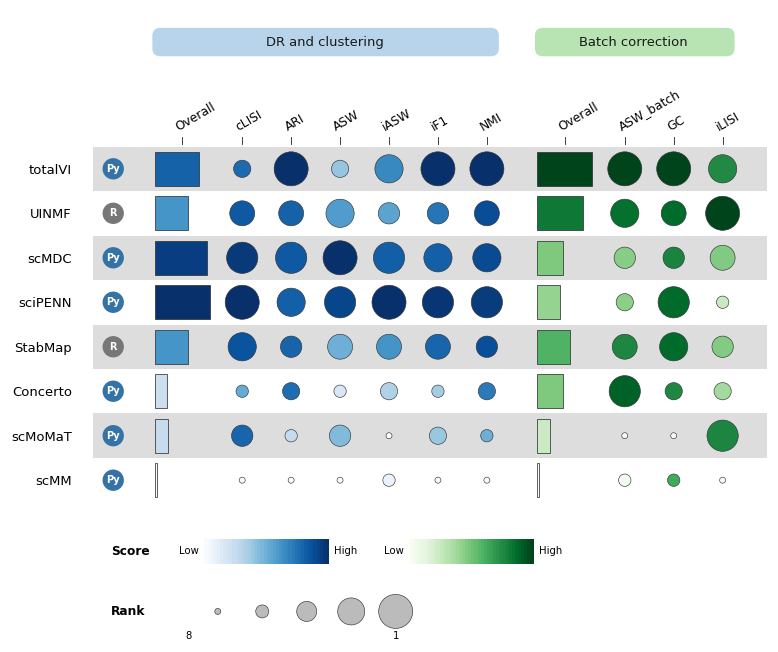

In [13]:
long = pd.read_csv(RESULTS / "long_all_D52.csv")
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

**Across datasets.** The summary figure needs every method to have results on
every dataset it is averaged over - otherwise absence and performance get mixed
into the same bar. The results folder therefore ships TWO cross datasets swept
with the same benchmark: `D52` and `D52s` (a 60% cell subsample of `D52`
under a new name). The code keeps the **intersection** of methods present in
both, so the matrix behind the figure is complete by construction - copy this
pattern with your own same-category datasets. The encoding is the paper's:
each metric's bar is its **grand rank** - the min-max scaled mean rank across
the datasets - with length and colour both carrying it, and `Overall` is the
min-max scaled mean rank of the grand ranks, exactly as in the paper's summary
panels. Both metric families appear because both datasets are multi-batch.

8 methods with results on both datasets


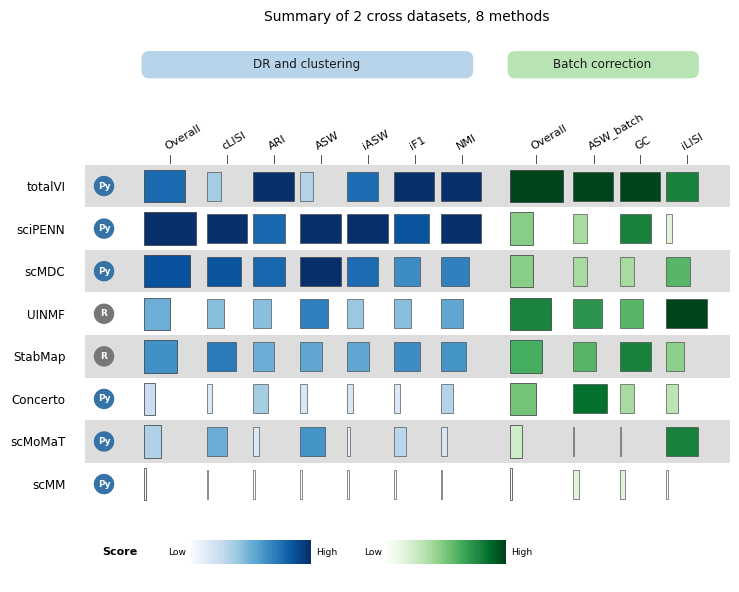

In [14]:
a = pd.read_csv(RESULTS / "long_all_D52.csv").assign(dataset="D52")
b = pd.read_csv(RESULTS / "long_all_D52s.csv").assign(dataset="D52s")
both = sorted(set(a.method) & set(b.method))   # complete matrix, by construction
pair = pd.concat([a, b], ignore_index=True)
pair = pair[pair.method.isin(both)]
print(f"{len(both)} methods with results on both datasets")
mtb.plot.bubble(pair, aggregate="summary",
                title=f"Summary of 2 cross datasets, {len(both)} methods")

## 9. Your own dataset - for real

Everything above used shipped data. This section does what you will actually do:
put files in a folder, point the package at it, and get scored results - executed
here on a dataset the package has never seen (a 60% cell subsample of
`D52` under a new name, built with ordinary h5py/pandas code you can
adapt to your own export pipeline).

In [15]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

In [16]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D52"
if src.is_dir():
    subsample_dataset(src, f"{DATA_ROOT}/MYDATA_cross", frac=0.6)
    sc = mtb.scan(f"MYDATA_cross", category=CATEGORY, data_path=DATA_ROOT)
    print(f"{int(sc.runnable.sum())} of {len(sc)} methods can run on MYDATA_cross")
else:
    print("skipped - benchmark data not downloaded; see section 1")

8 of 12 methods can run on MYDATA_cross


In [17]:
if CAN_RUN:
    mine = mtb.run_all(f"MYDATA_cross", CATEGORY,
                       methods=['UINMF', 'sciPENN', 'StabMap'],
                       out_dir=f"{DATA_ROOT}/out_cross",
                       data_path=DATA_ROOT)
    display(mine.summary)
else:
    print("skipped - running methods needs their conda environments;",
          "the status line under section 1 says exactly what to install")

[run_all] StabMap (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (23.5s) 0.6987


[run_all] UINMF (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (25.6s) 0.6521


[run_all] sciPENN (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (29.6s) 0.7424


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI
0,StabMap,CHAIN_OK,23.5,embedding,"[14085, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8245,0.6987,0.7771,0.5532,0.5624,0.6621,0.9915,0.9180,0.9256,0.5592
1,UINMF,CHAIN_OK,25.6,embedding,"[8857, 30]",0,cty1.csv+cty2.csv,0.9992,0.6521,0.7728,0.5646,0.5632,0.6107,0.9894,0.9284,0.9371,0.8824
2,sciPENN,CHAIN_OK,29.6,embedding,"[14085, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8276,0.7424,0.8032,0.6138,0.6218,0.7264,0.9967,0.8728,0.9270,0.4495


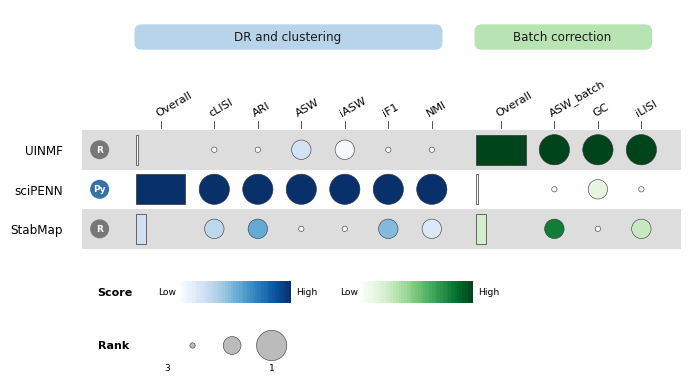

In [18]:
if CAN_RUN:
    display(mine.plot())
else:
    print("skipped - running methods needs their conda environments;",
          "the status line under section 1 says exactly what to install")

All three reached CHAIN_OK on this subsample when we ran them; `run_sec` above is the measured time.

For your real data the only work is producing the canonical files: export each
modality with `mtb.io.to_canonical` (from `.h5ad`) or the h5py pattern above,
write one label CSV per the layout in section 2, and the same three calls -
`scan`, `run_all`, `plot` - do the rest.

## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `scan` says not runnable: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `scan` says env missing | that method's conda env is not built | `multibench env install --run` |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |

### Note - spatial registration

`PASTE`, `PASTE2`, `SPIRAL` and `GPSA` are cross-integration methods whose output
is **aligned spatial coordinates**, not an embedding - their status reports
`RUN_OK_NO_EMBEDDING` and clustering metrics genuinely do not apply. Point them
at a directory of spatial slices (see `mtb.scan("D63", category="cross")`).

## Next steps

- the other three tutorials: **vertical**, **diagonal**, **mosaic**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `SETUP.md` - measured install cost and the smallest end-to-end check
- `mtb.method_info(name)` - everything the registry knows about one method
- `mtb.sweep(...)` - one method over a range of one hyperparameter